# W03A · 트랜스포머에서 텍스트 생성 웹앱까지
2026-09-14 월요일 · 3주차 1차시 · 교재 2.2–2.7

[강의노트](https://github.com/lunalab-ai/genAI/blob/main/course/notion/w03a/w03a-transformers.md)
· [기존 2주차 앱](https://github.com/lunalab-ai/genAI/blob/2026-fall-explained/notebooks/student/w02b_language_model_applications.ipynb)

**수업 버전:** `luna-genai 0.1.3`, 고정 ref `2026-fall-w03a`를 사용한다.
Colab에서 내 Drive에 사본을 저장하고 첫 셀부터 실행한다. 기존 2주차 사본은 유지한다.
공개 모델 약 1 GB를 처음 내려받는다. API 키·파일 업로드는 필요 없다. CPU 기본이다.
실제 모델 실패는 오류로 남기며 가짜 텍스트로 대체하지 않는다.

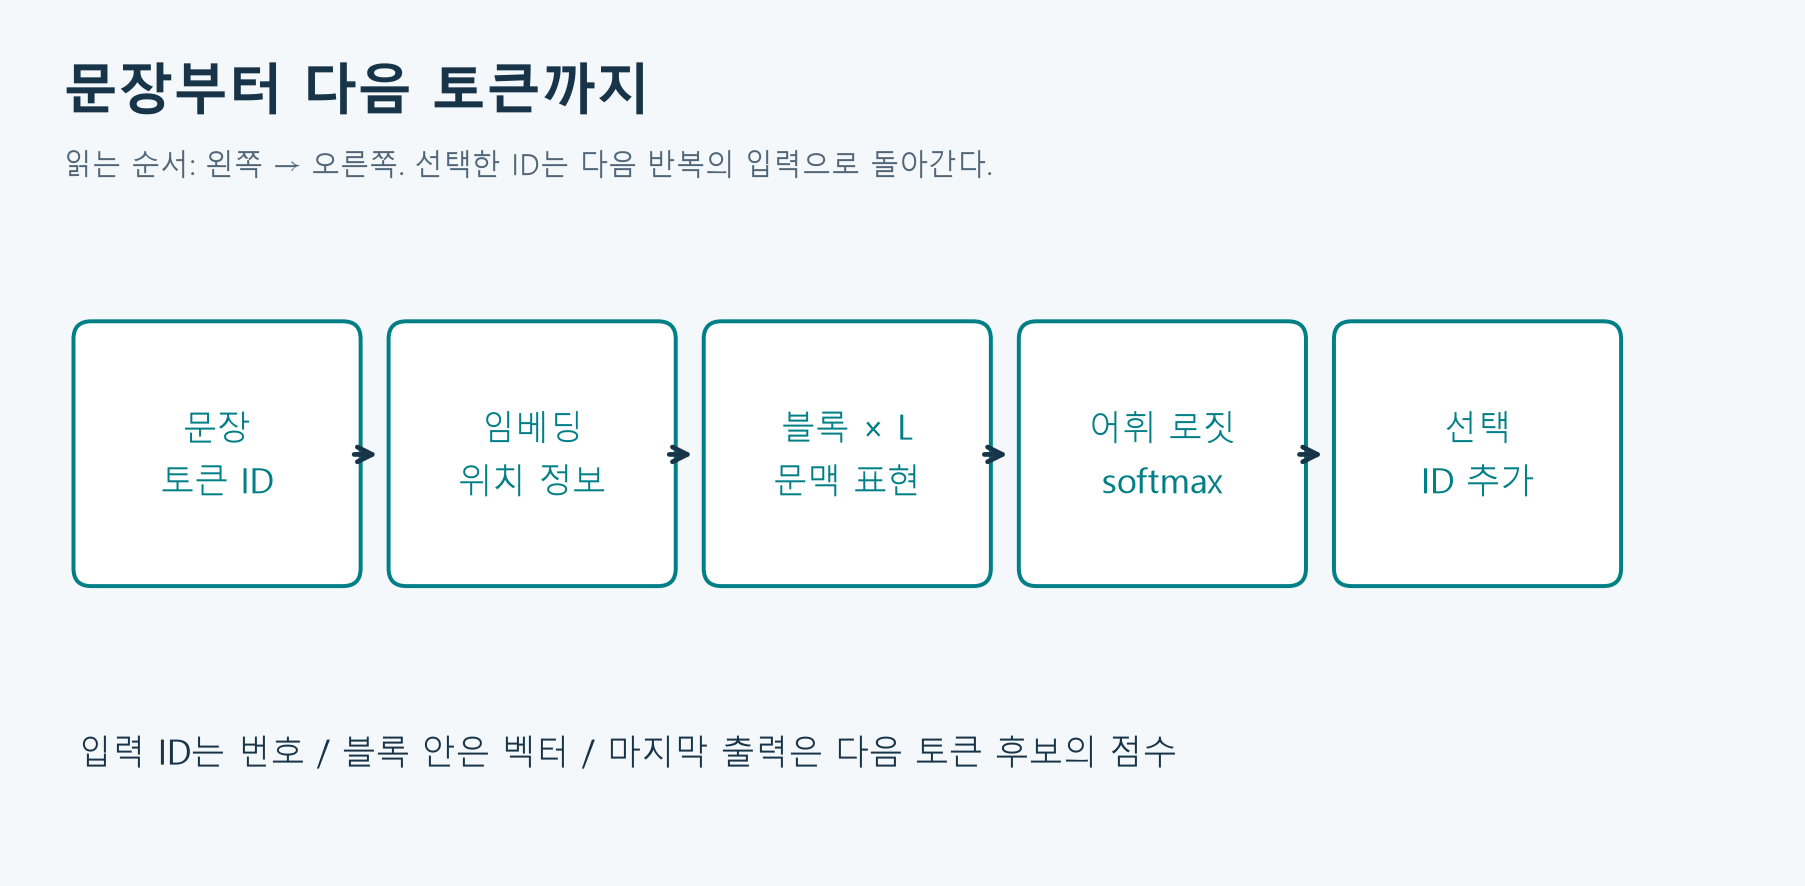
그림: 자체 제작. 각 단계의 출력과 다음 입력을 연결한다.
그림은 attachment로 포함하므로 별도 이미지 파일을 올리지 않아도 된다.


[Figure source](https://raw.githubusercontent.com/lunalab-ai/genAI/main/course/notion/w03a/assets/01-pipeline.png)


## 0. 설치와 모델 준비
`luna-genai`는 이전 수업의 모델 로더를 보존하며 W03A 계산 도구를 추가한 0.1.3이다.
`src`는 공통 모듈, notebook은 설명·실험·문제·UI 연결을 담당한다.
기존 설치를 이미 import한 상태에서 버전을 바꾸면 런타임을 재시작해야 한다.
설치는 다운로드/환경 변경을 수행하며, 이후의 수치 함수는 학습을 수행하지 않는다.


In [ ]:
import sys, subprocess
from pathlib import Path
from importlib.metadata import version, PackageNotFoundError

PUBLIC_REF = '2026-fall-w03a'  # 이 수업의 고정 공개 버전
try:
    ready = (version('luna-genai')=='0.1.3' and version('transformers')=='5.15.1'
             and version('gradio')=='6.26.0')
except PackageNotFoundError:
    ready = False
if not ready:
    if any(m in sys.modules for m in ('luna_genai','transformers','gradio')):
        raise RuntimeError('런타임을 재시작하고 첫 셀부터 실행하세요.')
    if Path('src/pyproject.toml').exists():
        package = str(Path('src').resolve())
    elif PUBLIC_REF:
        package = f'git+https://github.com/lunalab-ai/genAI.git@{PUBLIC_REF}#subdirectory=src'
    else:
        raise RuntimeError('공개 전 검토본입니다. 현재는 전체 과목 로컬 사본에서 실행하세요. 공개 후 확인된 Colab 링크를 사용합니다.')
    subprocess.run([sys.executable,'-m','pip','install','-q',package],check=True)
from luna_genai.runtime import prepare_text_runtime
prepare_text_runtime(repair_optional=True)
print('실습 환경:',sys.version.split()[0],version('luna-genai'),version('transformers'),version('gradio'))


### 처음 사용할 API 읽기
기존 공개 정의: [LanguageModelLab](https://github.com/lunalab-ai/genAI/blob/2026-fall-explained/src/luna_genai/model.py#L13).
생성자 `device='auto'`, `local_files_only=False`: 모델을 한 번 로드한다. auto는 CUDA가 가능하면
GPU, 아니면 CPU다. 최초 고정 revision 다운로드, 이후 캐시를 사용한다. CPU는 float32다.
저장된 tokenizer/model/device를 재사용하고 학습하지 않는다. 실패하면 RuntimeError다.
`lab.token_table(text)`는 입력 위치·ID·내부 표기·개별 decode의 DataFrame이다.
text는 비어 있지 않은 1500자·384토큰 이하 문자열. 아래 예의 행 수는 실제 분할에 따른다.
`lab.last_logits(text)`는 다음 토큰의 전체 어휘 로짓 [V]를 CPU float Tensor로 반환한다.

새 정의는 [transformer.py](https://github.com/lunalab-ai/genAI/blob/2026-fall-w03a/src/luna_genai/transformer.py#L10)다.
[함수별 정의 링크와 계약](https://github.com/lunalab-ai/genAI/blob/2026-fall-w03a/src/W03A-API.md)을 먼저 읽는다.
- `toy_attention(causal=True)` → 교육용 A (3,3), Z (3,2). 실제 모델 어텐션이 아니다.
- `attention(q,k,values,causal=False)` → (nq,nk) 가중치, (nq,dv) 출력. 행별 softmax.
- `layer_norm(x,eps=1e-5)` → 마지막 축을 정규화한 같은 모양 배열. gamma=1,beta=0 고정.
- `prompt_ids(lab,prompt)` → [1,n] LongTensor, 위 입력 제한 적용, 학습/다운로드 없음.
- `forward_logits(lab,ids)` → [V] CPU 로짓. 캐시 없이 실제 forward 한 번, 입력 길이 최대 416.
- `choose_token(logits,strategy='greedy',temperature=.8,top_k=0,rng=None)` →
  id, model_probability, selection_probability dict. sample은 NumPy Generator 필수.
- `append_token(lab,ids,next_id)` → [1,n+1] 새 ID tensor. 원래 입력 변경·재토큰화 없음.
- `trace_row(lab,step,choice)` → 표의 한 행. step은 표시 번호, token은 단일 decode의 repr.
- `one_token_callback(lab)` → 실제 한 단계 관찰 함수. 자동 반복을 대신하는 답안이 아니다.
- `build_transformer_app(lab,generate_callback=None)` → Gradio Blocks. 기본은 한 토큰 모드.
  callback 입력은 문장/규칙/온도/top-k/seed/길이, 반환은 전체 문장/DataFrame/종료 이유.
  모델을 로드하거나 서버를 시작하지 않는다. `launch()`는 별도 호출이다.
- `feed_forward(x,w1,w2,b1=None,b2=None)` → ReLU FFN 결과 ndarray. 마지막 특징 축만 변환한다.
  x(...,d), w1(d,m), w2(m,dout), bias 기본 0. 실제 Qwen SwiGLU가 아닌 수계산 검증용이다.


In [ ]:
import numpy as np
import pandas as pd
import torch
from IPython.display import display
from luna_genai import LanguageModelLab, MODEL_ID, MODEL_REVISION
from luna_genai.transformer import (attention,toy_attention,layer_norm,prompt_ids,
                                    forward_logits,choose_token,append_token,trace_row,
                                    one_token_callback,build_transformer_app,feed_forward)
lab=LanguageModelLab()
print('실제 모델:',MODEL_ID,MODEL_REVISION,'device:',lab.device)
display(lab.token_table('The sky is'))
config=lab.model.config
display(pd.DataFrame({'항목':['블록','특징 폭','Query heads','KV heads','FFN 폭'],
                      '값':[config.num_hidden_layers,config.hidden_size,config.num_attention_heads,
                            config.num_key_value_heads,config.intermediate_size]}))


## 1. 블록 계산을 작은 숫자로 보기
아래는 실제 모델에서 추출한 값이 아니다. 강의 수계산용 Q/K/V를 사용한다.
$$A=\operatorname{softmax}_{\mathrm{row}}(QK^\top/\sqrt{d_k}+M),\qquad Z=AV_m.$$
A의 행은 정보를 받는 위치, 열은 참고하는 위치다. Z의 열은 Value의 특징이다.
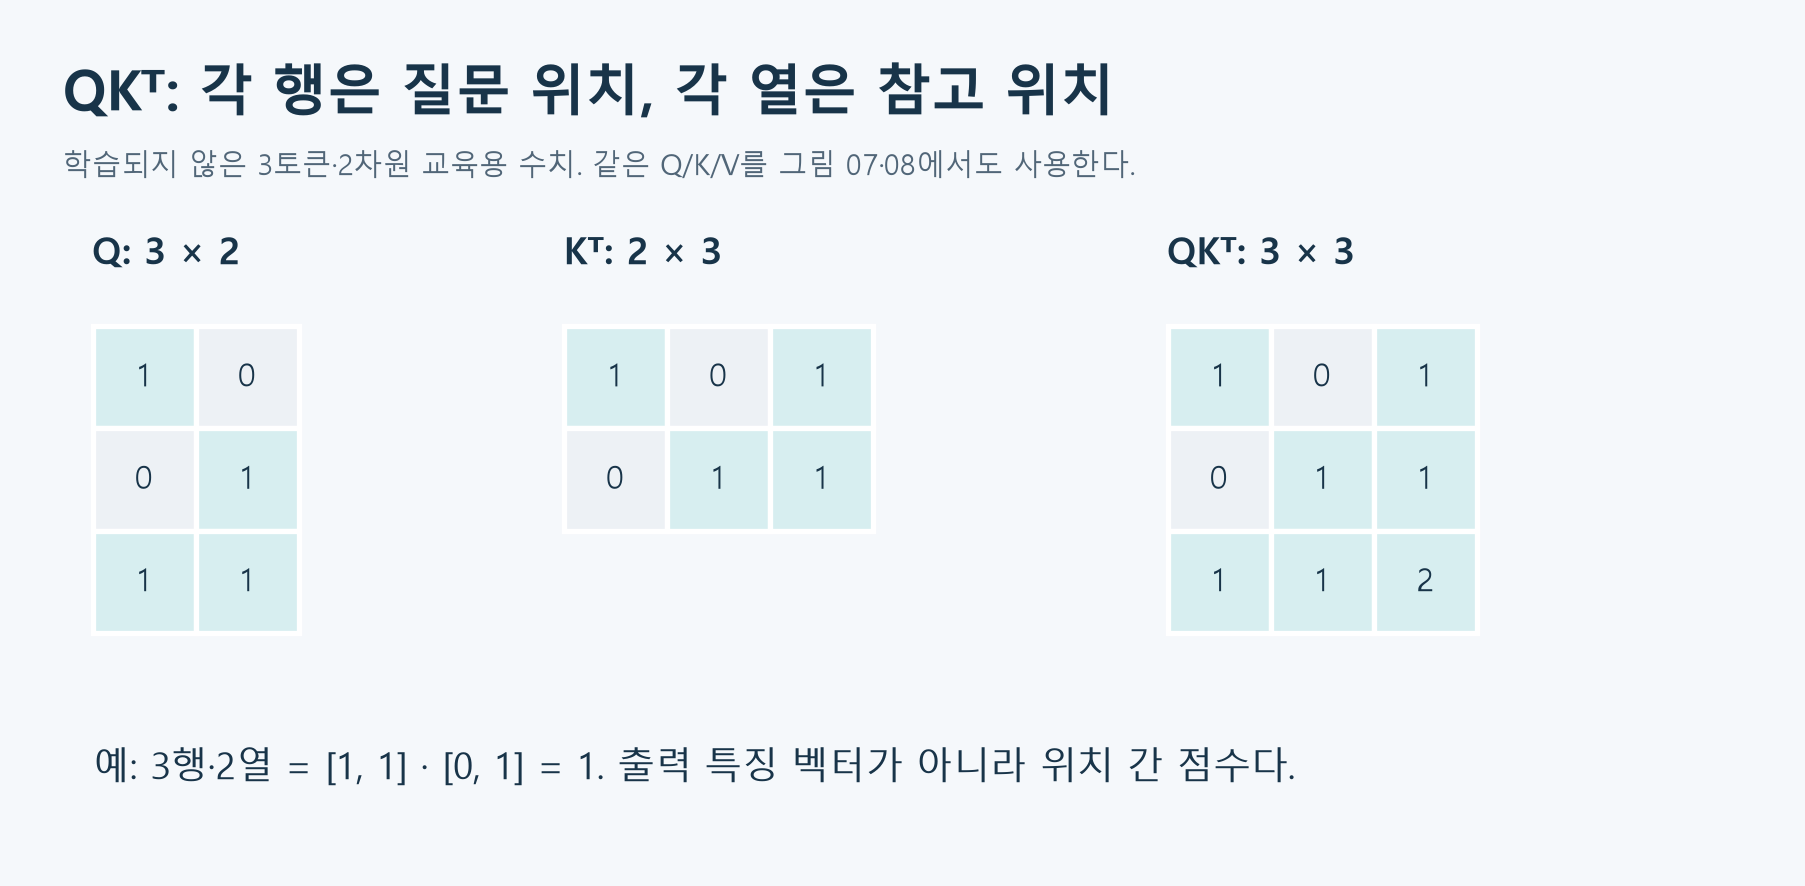
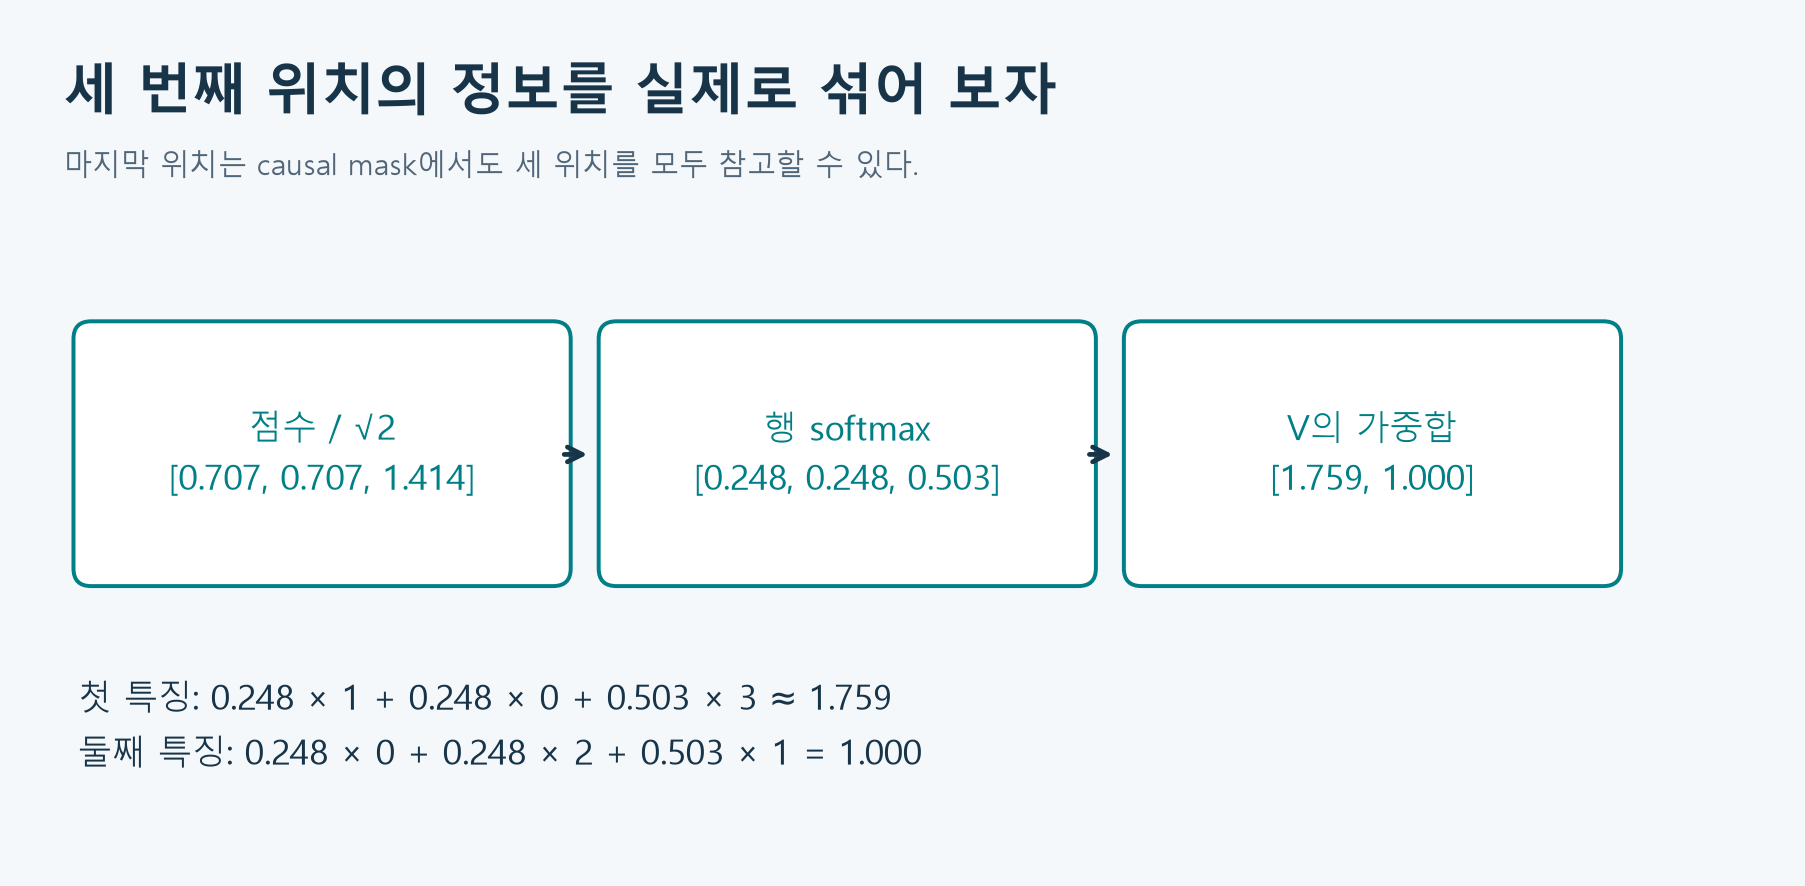


[Figure source](https://raw.githubusercontent.com/lunalab-ai/genAI/main/course/notion/w03a/assets/06-scores.png) · [Figure source](https://raw.githubusercontent.com/lunalab-ai/genAI/main/course/notion/w03a/assets/07-weighted-values.png)


In [ ]:
a,z=toy_attention(causal=True)
display(pd.DataFrame(a,index=['위치1','위치2','위치3'],columns=['참고1','참고2','참고3']))
display(pd.DataFrame(z,columns=['특징1','특징2']))
print('행합:',a.sum(axis=1),'출력 형태:',z.shape)
bidirectional,_=toy_attention(causal=False)
print('양방향 첫 위치의 미래 참고 비중:',bidirectional[0,1:])
print('정규화 예:',layer_norm([[1.,3.],[2.,4.]]))


### FFN 수계산 보충
아래 가중치는 직접 정한 값이며 학습된 모델 값이 아니다. 첫 변환으로 특징 폭을 2에서 4로 늘린다.
$$x=[1,-1],\qquad xW_1=[1,-2,0,1],\qquad\operatorname{ReLU}(xW_1)=[1,0,0,1].$$
두 번째 변환 후 FFN 결과는 [0,2], 잔차 합은 [1,1]이다. 토큰별로 같은 가중치를 쓴다.


In [ ]:
w1=np.array([[1,-1,1,0],[0,1,1,-1]],dtype=float)
w2=np.array([[1,0],[0,1],[1,1],[-1,2]],dtype=float)
ffn_input=np.array([[1.,-1.]])
ffn_output=feed_forward(ffn_input,w1,w2)
print('확장:',ffn_input@w1,'활성화:',np.maximum(0,ffn_input@w1))
print('FFN:',ffn_output,'잔차 합:',ffn_input+ffn_output)


### A · 잘못된 축과 마스크 찾기
목표: 확률의 분모와 차단 위치를 이해한다.
아래 문자열의 두 오류를 고쳐 `attention_fix`에 설명을 적는다.
`scores[future] = 0; weights = exp(scores) / exp(scores).sum(axis=0)`
힌트: 참고할 위치들은 한 행 안에 있다. 0을 지수화하면 0이 아니다.
자가 점검: 각 행의 합이 1이고 미래 위치가 정확히 0이어야 한다.


In [ ]:
attention_fix = None  # 설명/수정 코드를 별도 셀에 작성. 기본 a,z를 덮어쓰지 않는다.


## 2. 실제 모델에서 딱 한 번 계산
[PyTorch inference_mode](https://docs.pytorch.org/docs/stable/generated/torch.autograd.grad_mode.inference_mode.html)는
gradient 추적 비용을 줄인다. [Tensor argmax](https://docs.pytorch.org/docs/stable/generated/torch.argmax.html)는
최대 원소의 인덱스다. [NumPy Generator](https://numpy.org/doc/stable/reference/random/generator.html)는
요청별 난수 상태를 유지한다. 같은 seed라도 하드웨어/소프트웨어가 다르면 결과가 달라질 수 있다.
`forward_logits` 내부는 `model(input_ids=ids,use_cache=False).logits[0,-1,:]`다.
마지막 입력 위치가 다음 토큰을 예측한다. 아래에서 모델 가중치는 변경되지 않는다.


In [ ]:
prompt='The sky is'
ids=prompt_ids(lab,prompt)
logits=forward_logits(lab,ids)
choice=choose_token(logits,strategy='greedy')
ids_next=append_token(lab,ids,choice['id'])
display(pd.DataFrame([trace_row(lab,1,choice)]))
print('입력/로짓/추가 후 모양:',tuple(ids.shape),tuple(logits.shape),tuple(ids_next.shape))
print('전체 decode:',lab.tokenizer.decode(ids_next[0],skip_special_tokens=True))


### B · 직접 생성 루프 조립
목표: model.generate 없이 자동 반복을 완성한다.
`student_generate(lab,prompt,strategy,temperature,top_k,seed,max_new_tokens)`를 작성한다.
① prompt_ids ② 요청당 rng 하나 ③ 반복 안 forward_logits → choose_token → append_token
④ trace_row 기록 ⑤ EOS이면 break ⑥ 전체 decode, DataFrame, 종료 이유 반환.
greedy부터 완성하고 sampling/top-k로 확장한다. 아래 순서 빈칸을 실제 함수로 바꾼다.
힌트: rng를 반복 안에서 같은 seed로 매번 초기화하지 않는다. 전체 ID를 재토큰화하지 않는다.
자가 점검: 최초 greedy ID는 위 choice와 같다. 표 행 수는 최대 새 토큰 수 이하다.
stop 검사 전에 선택 토큰을 기록한다. `max_new_tokens`는 입력을 제외한 추가 수다.


In [ ]:
student_generate = None
generation_steps = ['입력 준비','TODO: forward 결과에서 읽을 것','TODO: 선택 후 갱신할 것','TODO: 종료 조건']
# 완성 후 예: student_result = student_generate(lab,'The sky is','greedy',.8,0,7,8)


### C · 통제된 비교와 예상
목표: 한 번에 바꾸는 설정을 분리한다. 같은 프롬프트·길이에서 greedy와 sample을 비교하되
sampling 안의 temperature 비교는 top-k·seed를 고정한다. 출력이 반드시 달라지는가?
힌트: 같은 후보가 뽑힐 수 있으므로 '항상 다름'을 성공 조건으로 두지 않는다.
자가 점검: 바꾼 값, 고정한 값, 실제 문자열, 해석 한계를 기록한다.


In [ ]:
experiment_record={'prompt':prompt,'fixed_seed':7,'fixed_top_k':10,'observations':[]}
# 완성 함수가 없어도 한 단계 분포 비교를 아래 셀에서 독립 실행할 수 있다.


In [ ]:
single_comparison=[]
for temperature in (.4,1.2):
    picked=choose_token(logits,strategy='sample',temperature=temperature,top_k=10,rng=np.random.default_rng(7))
    single_comparison.append({'temperature':temperature,**picked})
display(pd.DataFrame(single_comparison))


## 3. 웹 화면 조립
[Gradio Blocks와 이벤트](https://www.gradio.app/guides/blocks-and-event-listeners):
`button.click(fn,inputs,outputs)`의 입력 목록 순서가 fn 인자 순서이며, 반환값 순서가 출력 순서다.
앱은 모델 준비와 별개다. `build_transformer_app`은 모델을 다시 로드하지 않는다.
기본 앱은 한 토큰 관찰 모드다. 자동 반복 문제를 완성하면 callback만 교체한다.
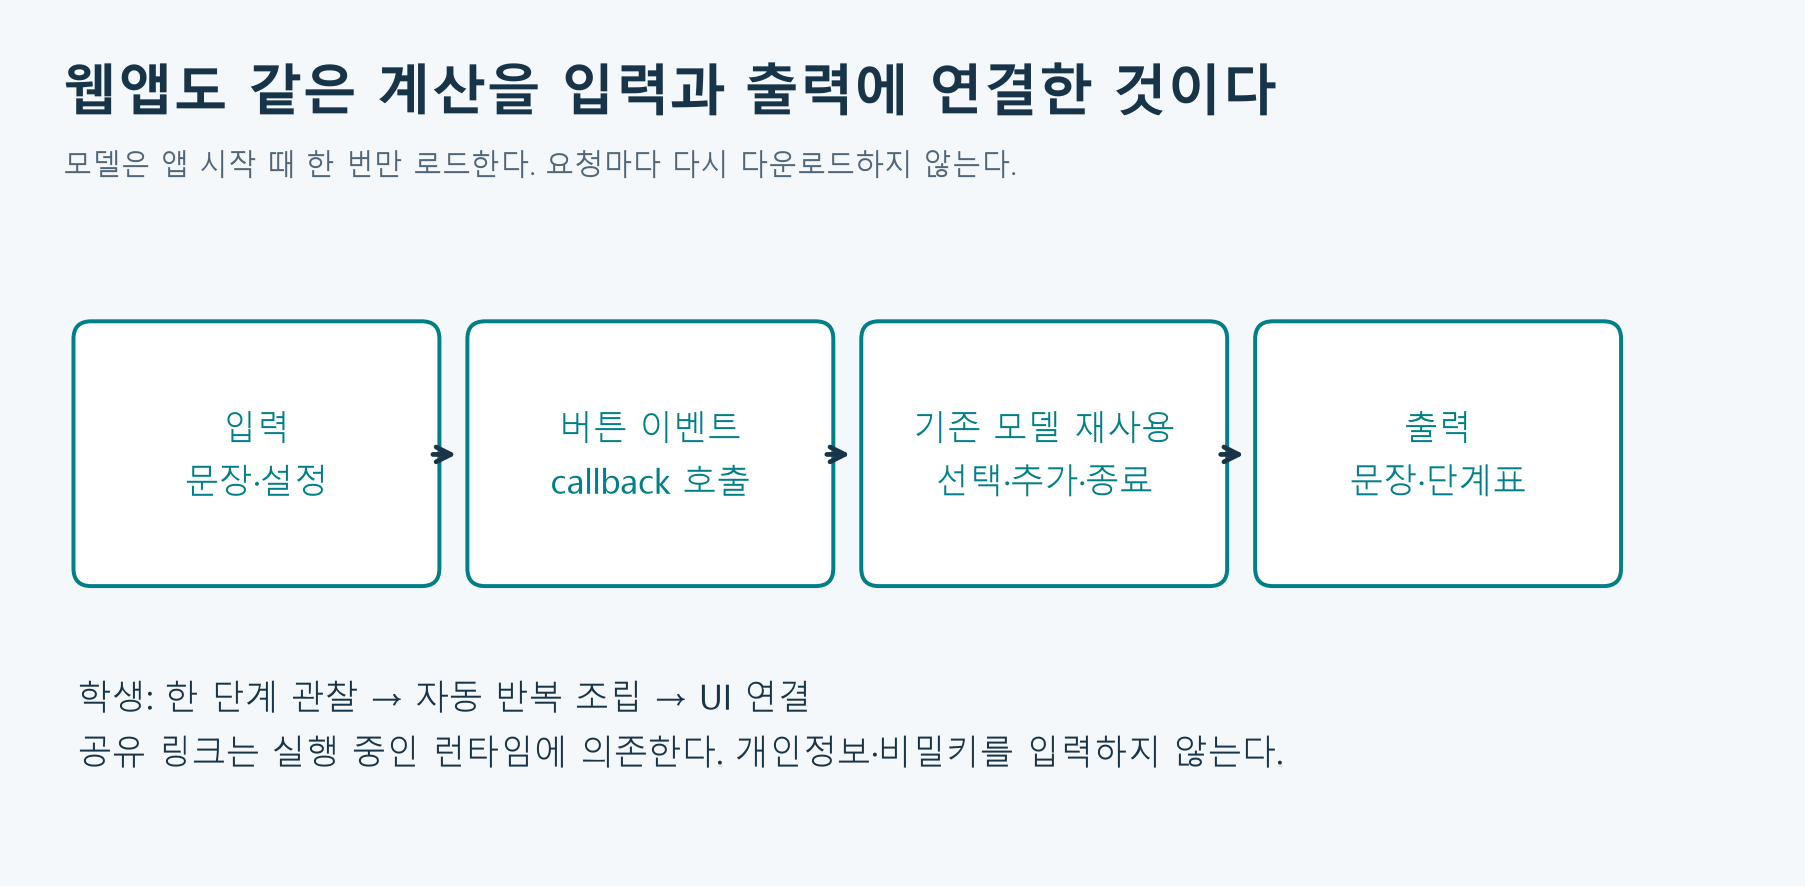


[Figure source](https://raw.githubusercontent.com/lunalab-ai/genAI/main/course/notion/w03a/assets/20-app.png)


### D · UI 입력과 자동 반복 연결
목표: 문장·규칙·온도·top-k·seed·길이를 생성 함수에 같은 의미로 전달한다.
`student_callback(prompt,strategy,temperature,top_k,seed,max_new_tokens)`를 만들고
전체 문자열, 단계표, 종료 이유 순서로 반환한다. 이를 build_transformer_app의 두 번째 인자로 넣는다.
힌트: 숫자 인자의 자리를 바꾸면 실행되어도 잘못된 실험이 된다. 모델은 함수 밖의 lab을 재사용한다.
자가 점검: 같은 설정의 직접 함수 호출과 callback 결과가 같아야 한다.


In [ ]:
student_callback = None
# 완성 후 student_app = build_transformer_app(lab,student_callback)


In [ ]:
app=build_transformer_app(lab,student_callback)
baseline_result=app.lesson_callback(prompt,'greedy',.8,0,7,8)
print(baseline_result[0]); display(baseline_result[1]); print(baseline_result[2])
if 'google.colab' in sys.modules:
    app.launch(share=True,debug=False)
else:
    print('로컬 검증: 앱 객체와 callback 확인. 화면을 열려면 app.launch(share=False)를 별도 실행하세요.')


### E · 모델 선택과 학습 여부 설명
목표: 단어 빈칸 복원, 문장 이어쓰기, 원문 요약에 맞는 계열을 고른다.
BERT·Qwen 기본 모델·T5/BART를 연결하고, 요약 프롬프트 예시를 넣었을 때 가중치가 바뀌는지 설명한다.
힌트: 정보 접근과 사전학습 목표가 근거다. 모델 이름만 나열하지 않는다.
자가 점검: T5를 decoder-only로 분류하지 않고, 작업별 미세조정 필요성도 구분한다.


In [ ]:
model_choice_note=None


## 4. 기본 실습 자동 점검
아래 셀은 미완성 문제의 정답을 요구하지 않는다. 가상 수치 불변량과 실제 모델·기본 callback을 확인한다.
검사는 CPU 로컬 실행 근거이며 실제 Colab UI/GPU/공개 링크 확인과는 구분한다.


In [ ]:
np.testing.assert_allclose(a.sum(1),np.ones(3),atol=1e-12)
assert np.count_nonzero(np.triu(a,1))==0 and z.shape==(3,2)
np.testing.assert_allclose(z[-1],[1.758724,1],atol=1e-5)
np.testing.assert_allclose(ffn_output,[[0.,2.]])
assert (ffn_input+ffn_output).shape==ffn_input.shape
assert config.hidden_size==896 and config.num_hidden_layers==24
assert logits.ndim==1 and len(logits)==config.vocab_size and torch.isfinite(logits).all()
assert choice['id']==int(logits.argmax())
assert ids_next.shape[1]==ids.shape[1]+1
assert len(baseline_result[1])==1 and len(baseline_result[0])>len(prompt)
assert 0<baseline_result[1].model_probability.iloc[0]<=1
assert app is not None and not lab.model.training
print('학생 기본 검사 통과: 수치·실제 모델·1단계 callback')


## 마무리
어텐션은 위치 간 참고 비중, FFN은 위치별 특징 변환, 출력 로짓은 다음 토큰 후보 점수다.
생성 루프의 선택·추가·종료를 완성하면 동일 함수를 화면에 연결할 수 있다.
공유 링크는 런타임이 살아 있을 때만 유지될 수 있다. 사용이 끝나면 앱과 런타임을 종료한다.
실험 결과는 별도 기록 양식에 남긴다. 지정된 성적 반영 과제·제출 기한은 없다.


In [ ]:
if 'google.colab' not in sys.modules:
    app.close()
